In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import tempfile, os
import gsw
from sklearn.mixture import GaussianMixture
from joblib import Parallel, delayed, cpu_count
import tqdm
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34, feature_histograms, plot_geo, plot_3d

In [2]:
# Get data into dataframe
df = pd.read_csv('WMA_fractions_v2_with_PV_GMM_ensemble.csv')

In [3]:
n_clusters = 6

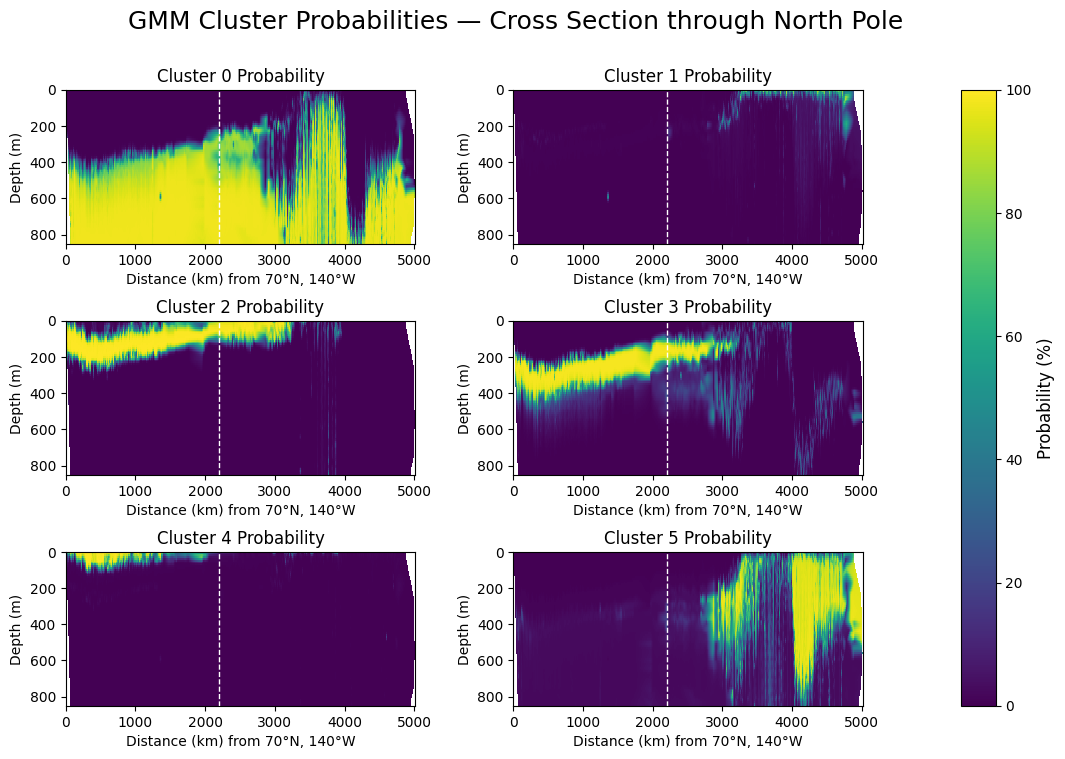

In [4]:
cross_sec_lon_prob2(df, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [5]:
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# Cross section like Kate's
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Geod
from matplotlib.colors import ListedColormap, BoundaryNorm

def compute_great_circle_distance_km(lat_ref, lon_ref, lats, lons):
    """Compute distance in km from a reference point along a great circle."""
    geod = Geod(ellps='WGS84')
    _, _, dist_m = geod.inv(
        np.full(len(lats), lon_ref),
        np.full(len(lats), lat_ref),
        lons,
        lats
    )
    return dist_m / 1000.0

def cross_sec_lon_var(
    df_sampled,
    n_clusters,
    lon_value,
    tol=0.5,
    start_lat=70.0,
    start_lon=-140.0,
    max_depth=850,
    depth_bin_size=10,
    dist_bin_size=2.2,
    browser=False
):
    # Antipodal longitude for the over-pole extension
    if lon_value < 0 and lon_value >= -180:
        lon_value = lon_value + 180
        
    # Primary slice from start_lon and secondary for lon_value intersecting at the pole
    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= start_lon - tol) &
        (df_sampled['Longitude_[deg_E]'] <= start_lon + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

    # Compute great-circle distance from start point
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat, start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # Bin coordinates
    df_lon_slice['depth_bin'] = (
        np.floor(df_lon_slice['Depth_[m]'] / depth_bin_size)
        * depth_bin_size
    )

    df_lon_slice['dist_bin'] = (
        np.floor(df_lon_slice['dist_km'] / dist_bin_size)
        * dist_bin_size
    )

    # Average probabilities within bins
    prob_cols = [f'var_per_sample_{i}' for i in range(n_clusters)]

    df_binned = (
        df_lon_slice
        .groupby(['dist_bin', 'depth_bin'])[prob_cols]
        .mean()
        .reset_index()
    )

    # Regular plotting grid
    xi = np.arange(
        df_binned['dist_bin'].min(),
        df_binned['dist_bin'].max(),
        dist_bin_size
    )

    yi = np.arange(
        0,
        max_depth + depth_bin_size,
        depth_bin_size
    )

    XI, YI = np.meshgrid(xi, yi)

    # Figure
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(int(np.floor(n_clusters/2)), int(np.floor(n_clusters/2)), 
                          width_ratios=[1, 1, 0.1], wspace=0.4, hspace=0.5)

    axes = []
    for i in range(int(np.floor(n_clusters/2))):
        for j in range(int(np.floor(n_clusters/3))):
            axes.append(fig.add_subplot(gs[i, j]))
    
    cax = fig.add_subplot(gs[:, 2])
    # Plot each field
    for i, ax in enumerate(axes):

        col = f'var_per_sample_{i}'
        # Interpolate onto regular grid
        ZI = griddata(
            (
                df_binned['dist_bin'],
                df_binned['depth_bin']
            ),
            df_binned[col] * 100,
            (XI, YI),
            method='linear'
        )

        # Smooth field
        ZI = gaussian_filter(ZI, sigma=1.0)

        # Plot
        pcm = ax.pcolormesh(
            XI,
            YI,
            ZI,
            shading='auto',
            cmap='viridis',
            vmin=0,
            vmax=np.nanmax(ZI))

        # Pole marker
        ax.axvline(
            2200,
            color='white',
            linestyle='--',
            linewidth=1)

        # Formatting
        ax.set_ylim(max_depth, 0)
        ax.set_title(f'Cluster {i} Variance')
        ax.set_xlabel(f'Distance (km) from 70°N, 140°W')
        ax.set_ylabel('Depth (m)')

    # Shared colorbar
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label('Variance', fontsize=12)

    # Title
    fig.suptitle(
        'GMM Cluster Variance — Cross Section through North Pole',
        fontsize=18,
        y=0.98
    )

    if browser:
        plt.show(renderer='browser')
    else:
        plt.show()

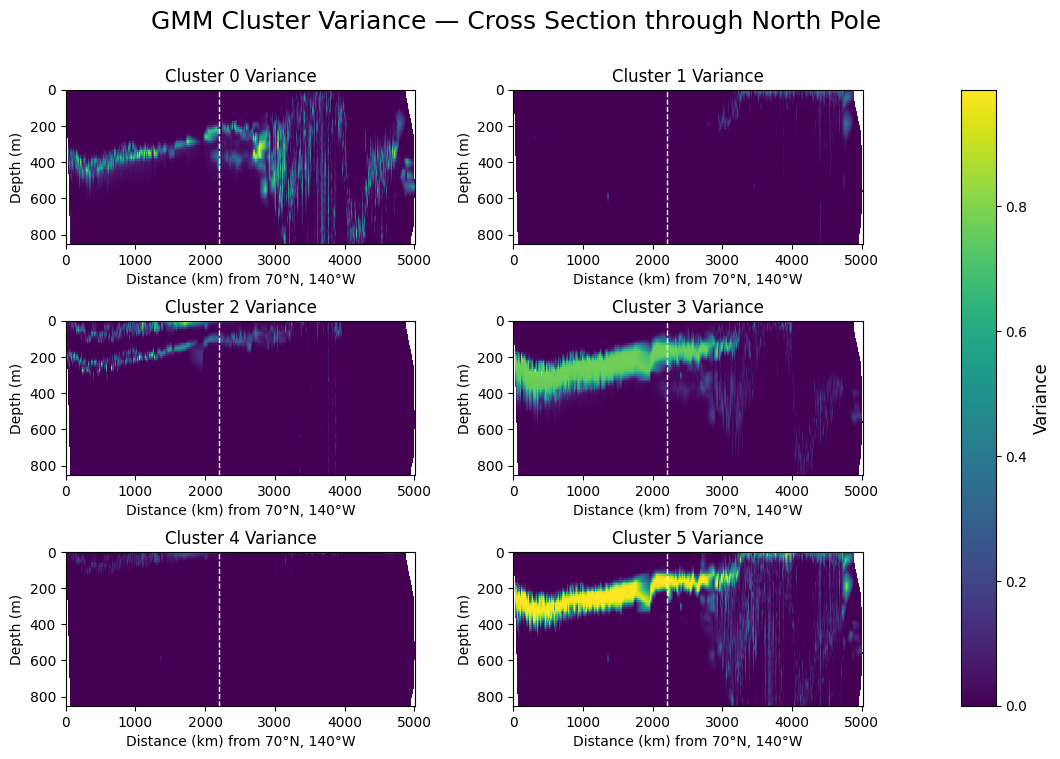

In [6]:
cross_sec_lon_var(df, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [9]:
import matplotlib as mpl

mpl.rcParams["agg.path.chunksize"] = 10000
mpl.rcParams["path.simplify"] = True
mpl.rcParams["path.simplify_threshold"] = 0.5

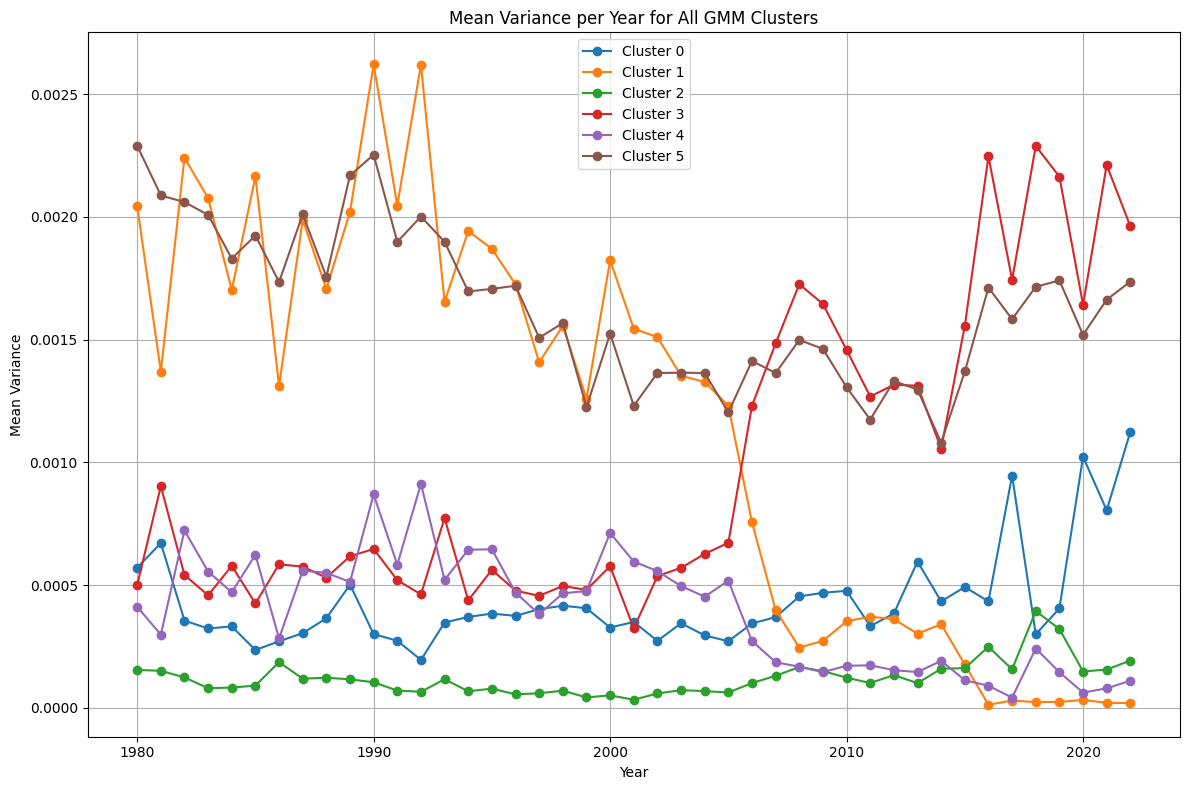

In [7]:
# Variance column names
var_cols = [f'var_per_sample_{i}' for i in range(n_clusters)]

# Mean variance per year for every cluster
yearly_vars = df.groupby('year')[var_cols].mean()

# Plot
plt.figure(figsize=(12, 8))

for i in range(n_clusters):
    col = f'var_per_sample_{i}'

    plt.plot(
        yearly_vars.index,
        yearly_vars[col],
        marker='o',
        label=f'Cluster {i}'
    )

plt.title('Mean Variance per Year for All GMM Clusters')
plt.xlabel('Year')
plt.ylabel('Mean Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

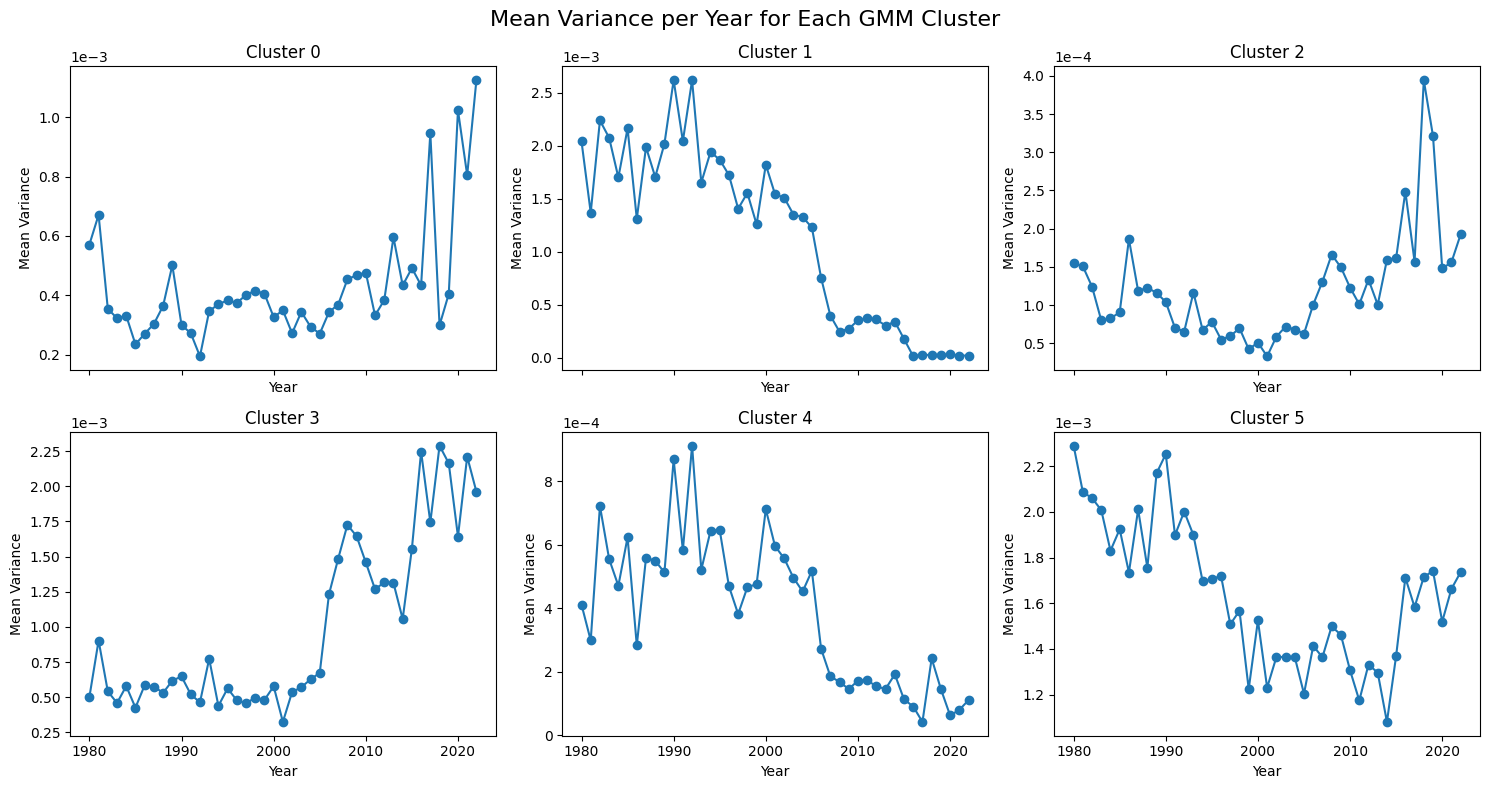

In [8]:
import matplotlib.pyplot as plt

# Variance column names
var_cols = [f'var_per_sample_{i}' for i in range(n_clusters)]

# Calculate mean variance per year for each cluster
yearly_vars = df.groupby('year')[var_cols].mean()

# Create a 2 x 3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

# Flatten axes for easy looping
axes = axes.flatten()

for i in range(n_clusters):
    col = f'var_per_sample_{i}'

    axes[i].plot(
        yearly_vars.index,
        yearly_vars[col],
        marker='o'
    )

    axes[i].set_title(f'Cluster {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Mean Variance')

    # Scientific notation on y-axis
    axes[i].ticklabel_format(
        axis='y',
        style='sci',
        scilimits=(0, 0)
    )

# Hide unused subplots
for j in range(n_clusters, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Mean Variance per Year for Each GMM Cluster', fontsize=16)

plt.tight_layout()
plt.show()

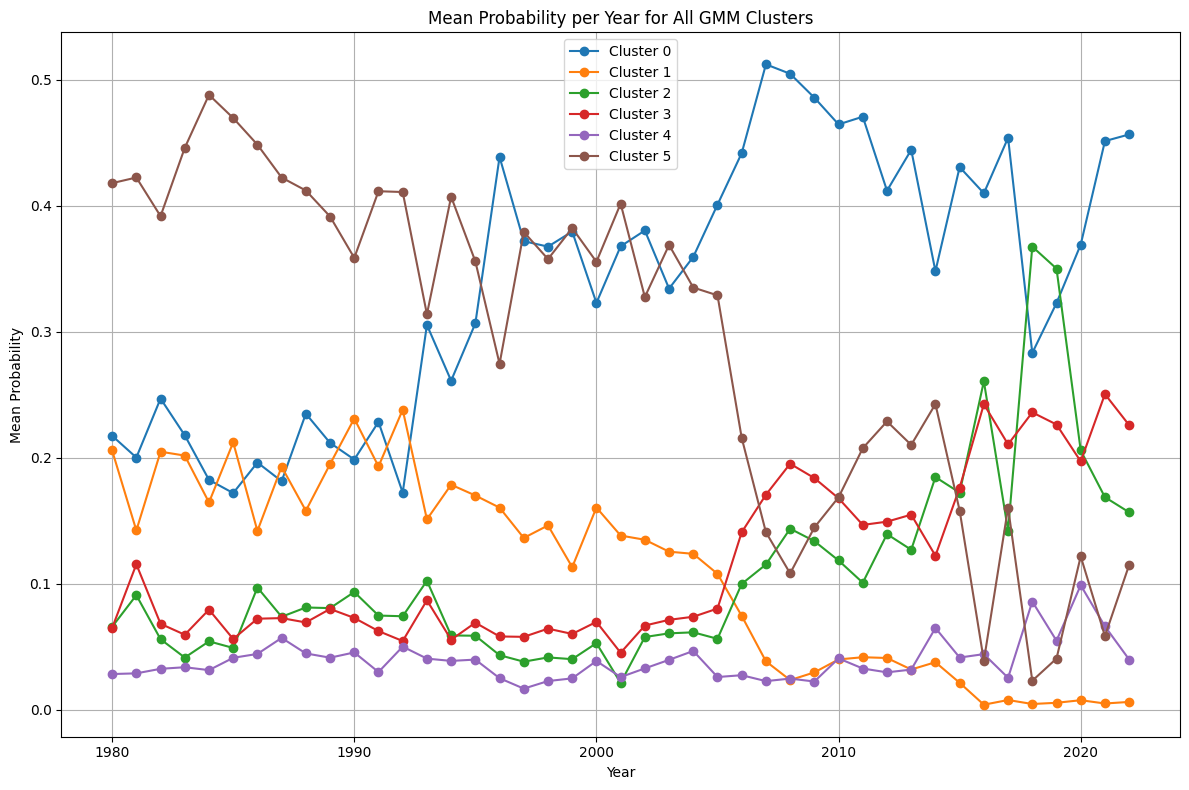

In [35]:
# Variance column names
var_cols = [f'prob_mean_cluster_{i}' for i in range(n_clusters)]

# Mean variance per year for every cluster
yearly_vars = df.groupby('year')[var_cols].mean()

# Plot
plt.figure(figsize=(12, 8))

for i in range(n_clusters):
    col = f'prob_mean_cluster_{i}'

    plt.plot(
        yearly_vars.index,
        yearly_vars[col],
        marker='o',
        label=f'Cluster {i}'
    )

plt.title('Mean Probability per Year for All GMM Clusters')
plt.xlabel('Year')
plt.ylabel('Mean Probability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

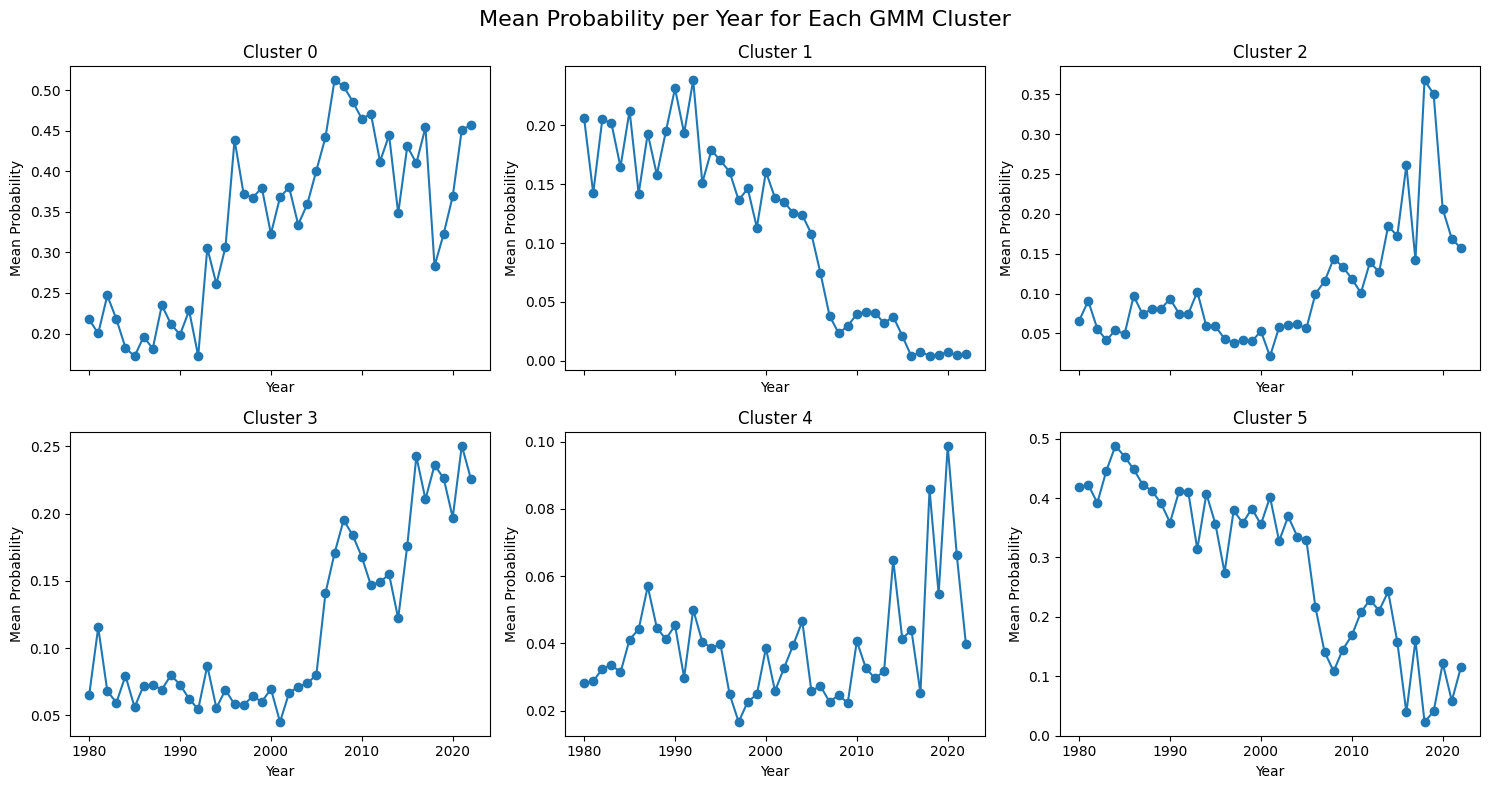

In [37]:
import matplotlib.pyplot as plt

# Variance column names
var_cols = [f'prob_mean_cluster_{i}' for i in range(n_clusters)]

# Calculate mean variance per year for each cluster
yearly_vars = df.groupby('year')[var_cols].mean()

# Create a 2 x 3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

# Flatten axes for easy looping
axes = axes.flatten()

for i in range(n_clusters):
    col = f'prob_mean_cluster_{i}'

    axes[i].plot(
        yearly_vars.index,
        yearly_vars[col],
        marker='o'
    )

    axes[i].set_title(f'Cluster {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Mean Probability')

# Hide unused subplots
for j in range(n_clusters, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Mean Probability per Year for Each GMM Cluster', fontsize=16)

plt.tight_layout()
plt.show()

In [9]:
df_80_00 = df[(df['year'] >= 1980) & (df['year'] <= 2000)]

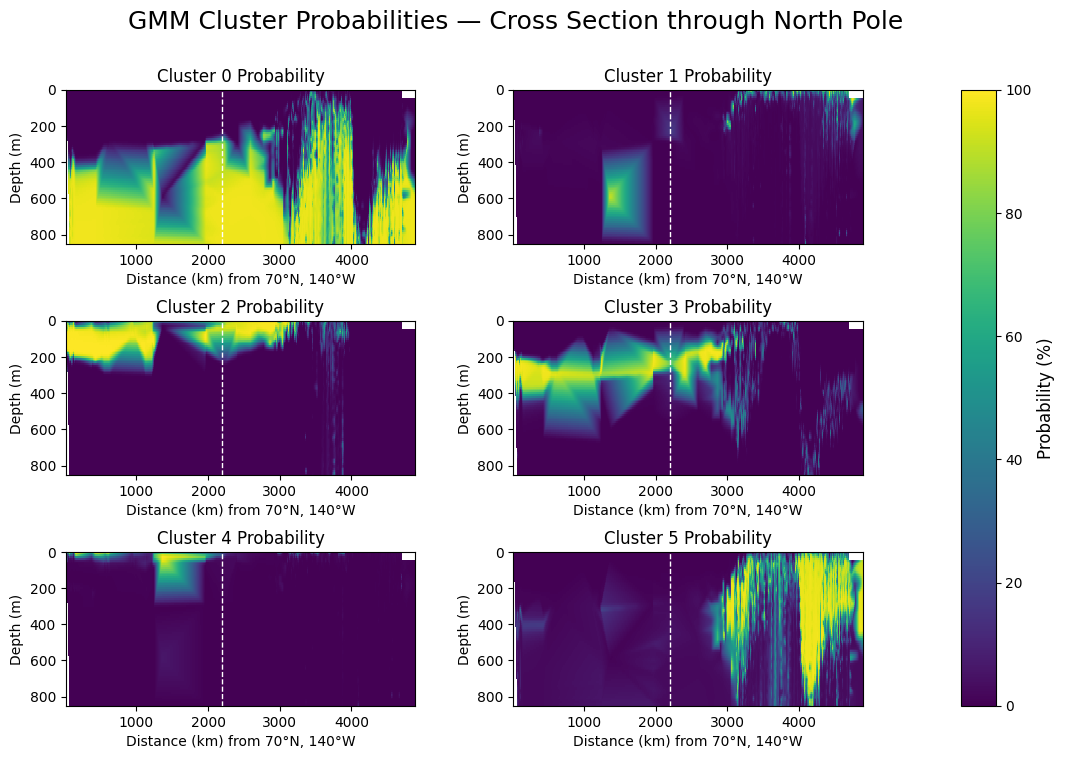

In [10]:
cross_sec_lon_prob2(df_80_00, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [11]:
df_00_23 = df[(df['year'] >= 2000) & (df['year'] <= 2023)]

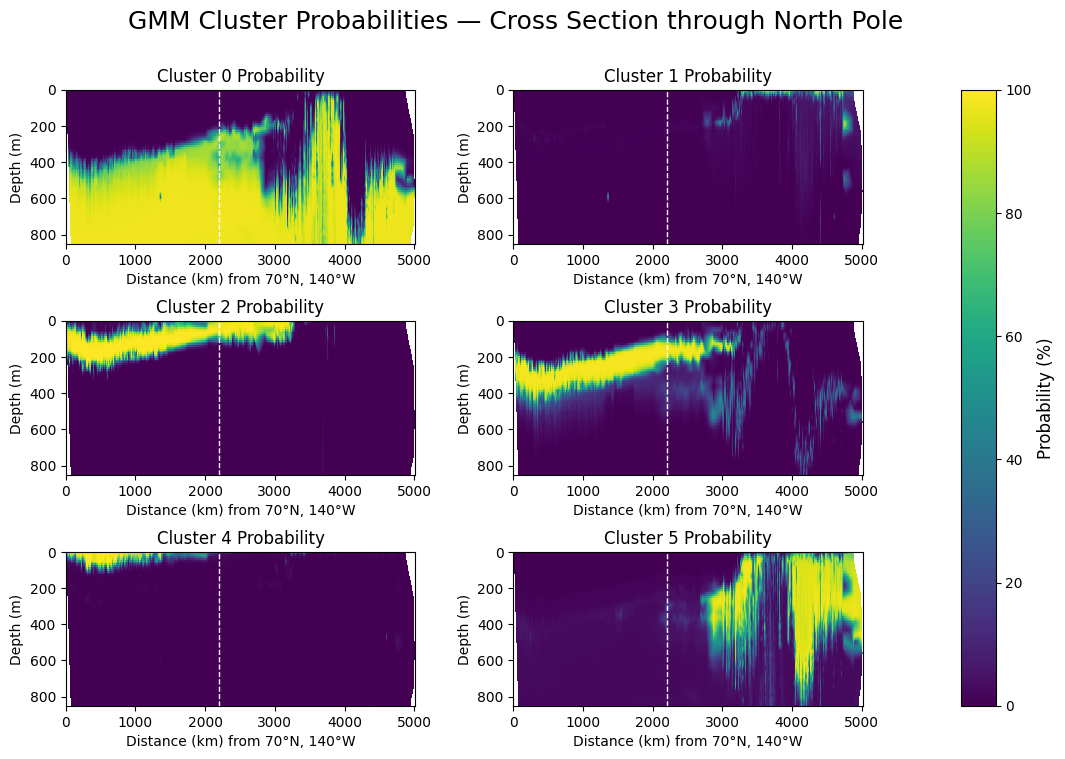

In [12]:
cross_sec_lon_prob2(df_00_23, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [ ]:
# Plot number of samples per year per cluster
plt.figure(figsize=(12, 6))
plt.bar(df['year'], df['var_per_sample_0'], color='blue', alpha=0.7)
plt.title('Number of Samples per Year for Cluster 0')
plt.xlabel('Year')
plt.ylabel('Number of Samples')

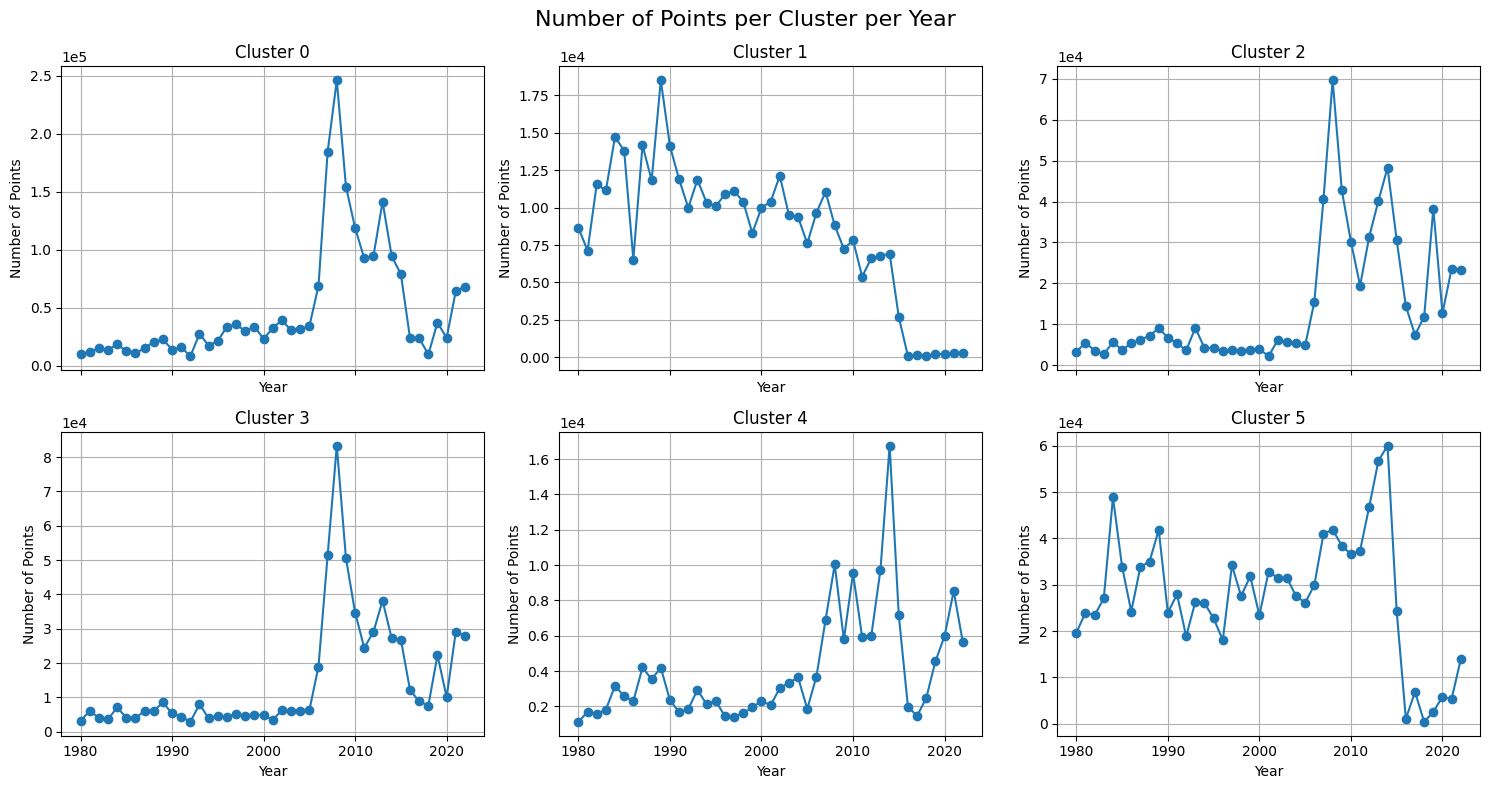

In [16]:
# Count points per cluster per year
yearly_counts = (
    df.groupby(['year', 'mean_cluster'])
      .size()
      .unstack(fill_value=0)
)

# Create 2 x 3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

axes = axes.flatten()

for i in range(n_clusters):

    # Get counts for cluster i
    if i in yearly_counts.columns:
        counts = yearly_counts[i]
    else:
        counts = 0

    axes[i].plot(
        counts.index,
        counts.values,
        marker='o'
    )

    axes[i].set_title(f'Cluster {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Number of Points')
    axes[i].grid(True)

    # Scientific notation on y-axis
    axes[i].ticklabel_format(
        axis='y',
        style='sci',
        scilimits=(0, 0)
    )

# Hide unused axes
for j in range(n_clusters, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Number of Points per Cluster per Year',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# Mean variance per year
yearly_vars = (
    df.groupby('year')[
        [f'var_per_sample_{i}' for i in range(n_clusters)]
    ].mean()
)

# Number of samples per cluster per year
yearly_counts = (
    df.groupby(['year', 'mean_cluster'])
      .size()
      .unstack(fill_value=0)
)

# Calculate Pearson correlation for each cluster
correlations = {}

for i in range(n_clusters):
    correlations[i] = yearly_counts[i].corr(
        yearly_vars[f'var_per_sample_{i}']
    )

correlations = pd.Series(correlations)

print(correlations)

0    0.135190
1    0.811535
2    0.396006
3    0.596684
4   -0.546675
5   -0.325952
dtype: float64


In [18]:
import pandas as pd

# Mean variance per year
yearly_vars = (
    df.groupby('year')[
        [f'prob_mean_cluster_{i}' for i in range(n_clusters)]
    ].mean()
)

# Number of samples per cluster per year
yearly_counts = (
    df.groupby(['year', 'mean_cluster'])
      .size()
      .unstack(fill_value=0)
)

# Calculate Pearson correlation for each cluster
correlations = {}

for i in range(n_clusters):
    correlations[i] = yearly_counts[i].corr(
        yearly_vars[f'prob_mean_cluster_{i}']
    )

correlations = pd.Series(correlations)

print(correlations)

0    0.715996
1    0.809956
2    0.502102
3    0.606566
4    0.275254
5    0.350248
dtype: float64


In [21]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Variance per year
var_cols = [f'var_per_sample_{i}' for i in range(n_clusters)]

yearly_vars = (
    df.groupby('year')[var_cols]
      .mean()
)

# Number of samples per cluster per year
yearly_counts = (
    df.groupby(['year', 'mean_cluster'])
      .size()
      .unstack(fill_value=0)
)

print("Variance columns:")
print(yearly_vars.columns)

print("\nCluster columns:")
print(yearly_counts.columns)

Variance columns:
Index(['var_per_sample_0', 'var_per_sample_1', 'var_per_sample_2',
       'var_per_sample_3', 'var_per_sample_4', 'var_per_sample_5'],
      dtype='str')

Cluster columns:
Index([0, 1, 2, 3, 4, 5], dtype='int64', name='mean_cluster')


In [22]:
decorrelated_vars = pd.DataFrame(index=yearly_vars.index)

for i in range(n_clusters):

    var_col = f'var_per_sample_{i}'

    # Make sure cluster i exists
    if i not in yearly_counts.columns:
        print(f"Cluster {i} not found in yearly_counts")
        continue

    data = pd.concat([
        yearly_counts[i].rename('n_samples'),
        yearly_vars[var_col].rename('variance')
    ], axis=1).dropna()

    # Regression: variance ~ number of samples
    X = sm.add_constant(data['n_samples'])
    y = data['variance']

    model = sm.OLS(y, X).fit()

    # Residual = variance after removing sample-number effect
    decorrelated_vars.loc[
        data.index,
        var_col
    ] = model.resid

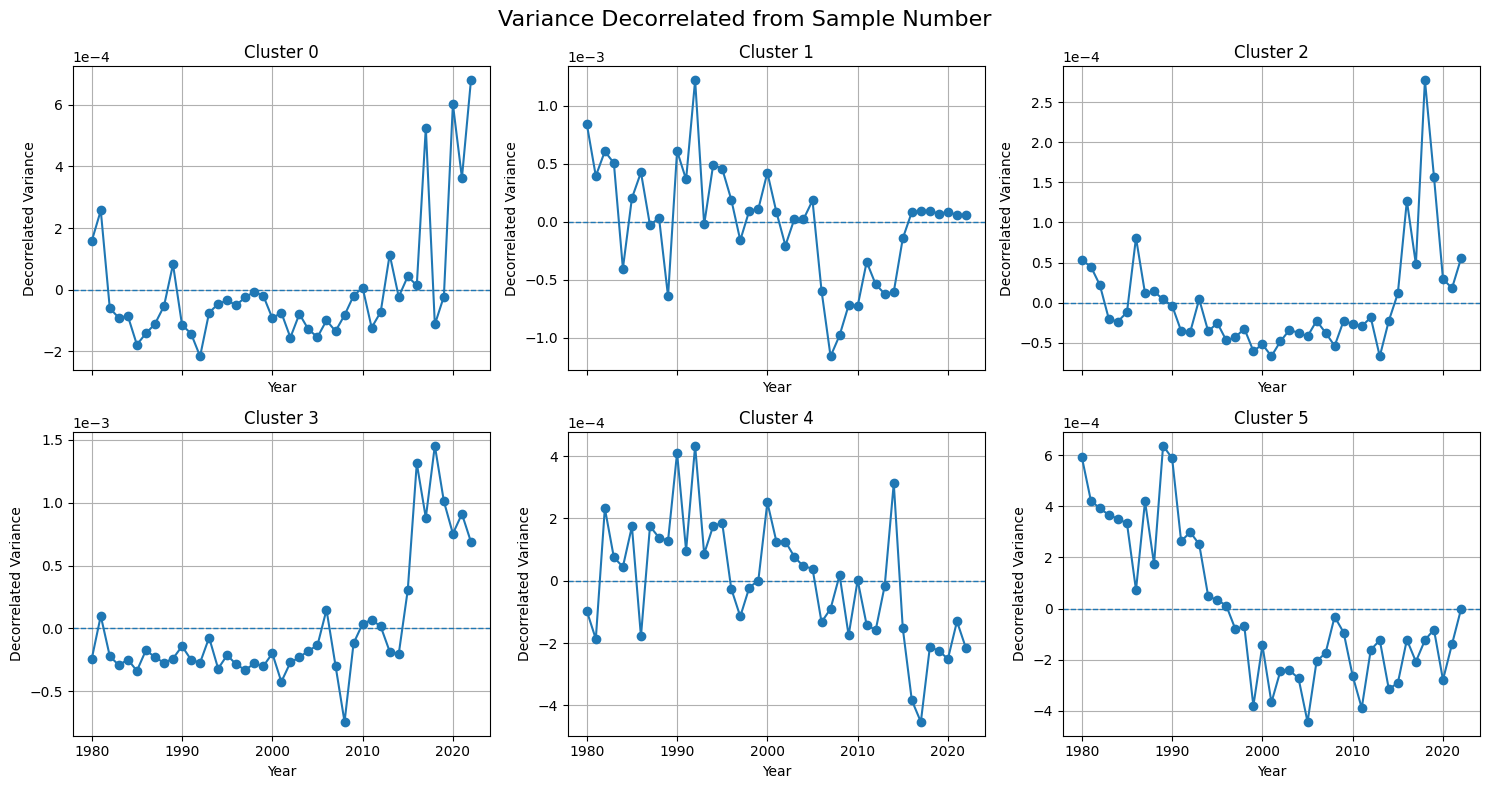

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i in range(n_clusters):

    col = f'var_per_sample_{i}'

    axes[i].plot(
        decorrelated_vars.index,
        decorrelated_vars[col],
        marker='o'
    )

    axes[i].axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    axes[i].set_title(f'Cluster {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Decorrelated Variance')
    axes[i].grid(True)

    axes[i].ticklabel_format(
        axis='y',
        style='sci',
        scilimits=(0, 0)
    )

for j in range(n_clusters, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Variance Decorrelated from Sample Number',
    fontsize=16
)

plt.tight_layout()
plt.show()

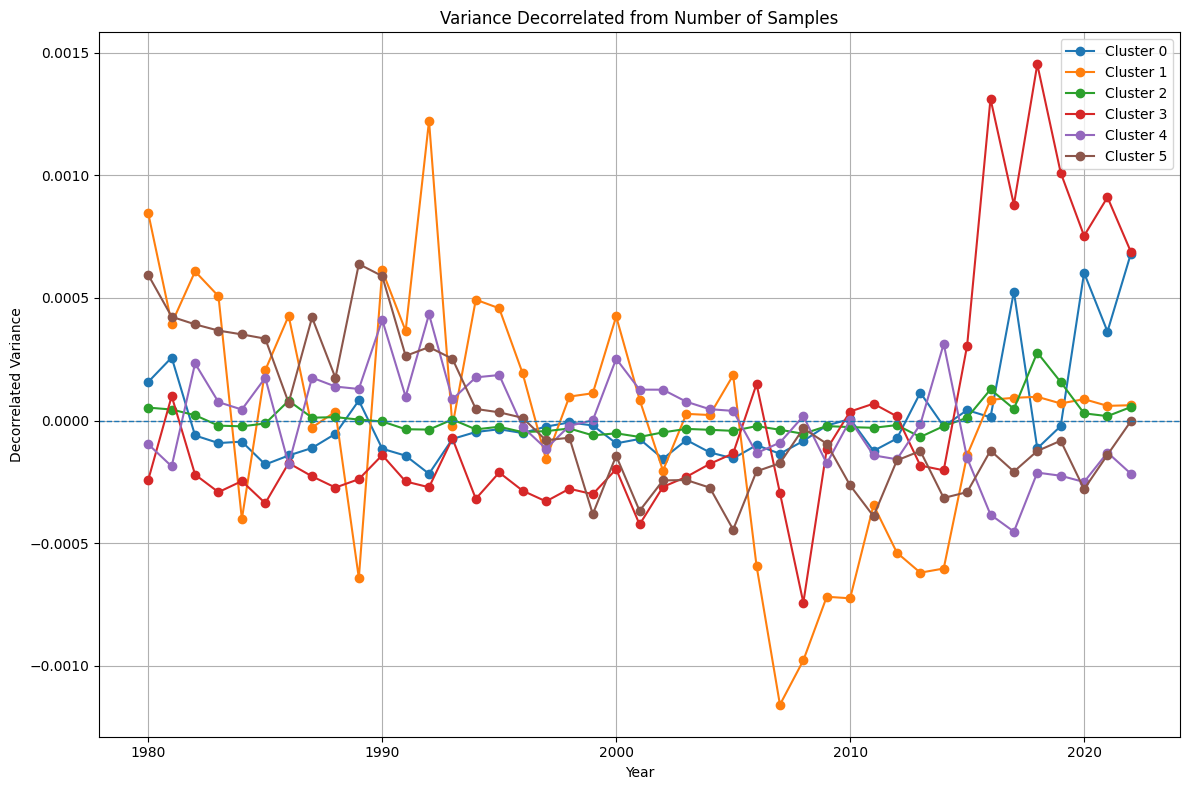

In [24]:
# Variance column names
var_cols = [f'var_per_sample_{i}' for i in range(n_clusters)]

# Plot decorrelated variance
plt.figure(figsize=(12, 8))

for i in range(n_clusters):
    col = f'var_per_sample_{i}'

    plt.plot(
        decorrelated_vars.index,
        decorrelated_vars[col],
        marker='o',
        label=f'Cluster {i}'
    )

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title('Variance Decorrelated from Number of Samples')
plt.xlabel('Year')
plt.ylabel('Decorrelated Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Variance column names
prob_cols = [f'prob_mean_cluster_{i}' for i in range(n_clusters)]

# Calculate mean variance per year for each cluster
yearly_probs = df.groupby('year')[prob_cols].mean()

decorrelated_probs = pd.DataFrame(index=yearly_probs.index)

for i in range(n_clusters):

    prob_col = f'prob_mean_cluster_{i}'

    # Make sure cluster i exists
    if i not in yearly_counts.columns:
        print(f"Cluster {i} not found in yearly_counts")
        continue

    data = pd.concat([
        yearly_counts[i].rename('n_samples'),
        yearly_probs[prob_col].rename('probability')
    ], axis=1).dropna()

    # Regression: variance ~ number of samples
    X = sm.add_constant(data['n_samples'])
    y = data['probability']

    model = sm.OLS(y, X).fit()

    # Residual = variance after removing sample-number effect
    decorrelated_probs.loc[
        data.index,
        prob_col
    ] = model.resid

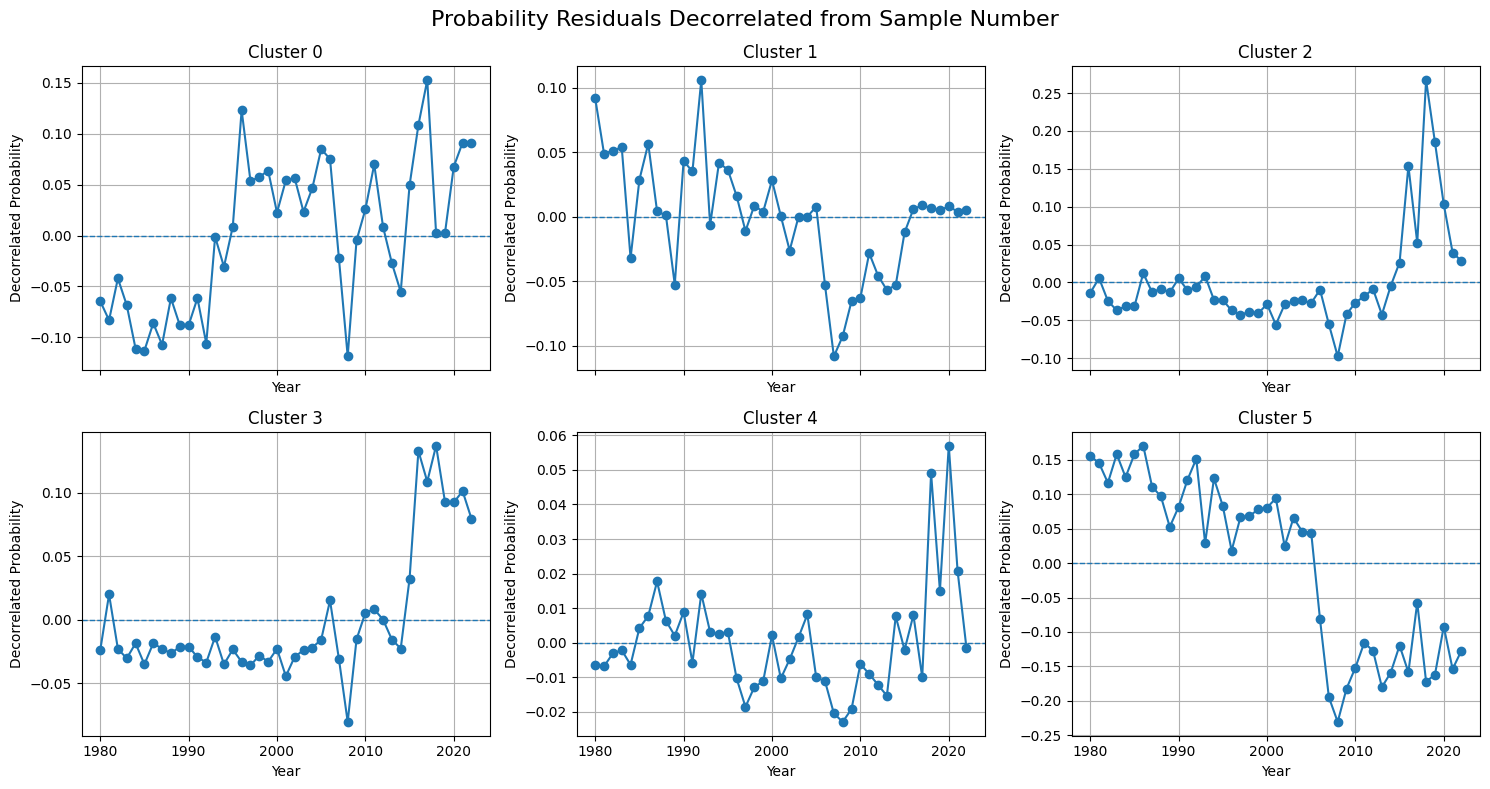

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for i in range(n_clusters):

    col = f'prob_mean_cluster_{i}'

    axes[i].plot(
        decorrelated_probs.index,
        decorrelated_probs[col],
        marker='o'
    )

    axes[i].axhline(
        0,
        linestyle='--',
        linewidth=1
    )

    axes[i].set_title(f'Cluster {i}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Decorrelated Probability')
    axes[i].grid(True)

for j in range(n_clusters, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Probability Residuals Decorrelated from Sample Number',
    fontsize=16
)

plt.tight_layout()
plt.show()

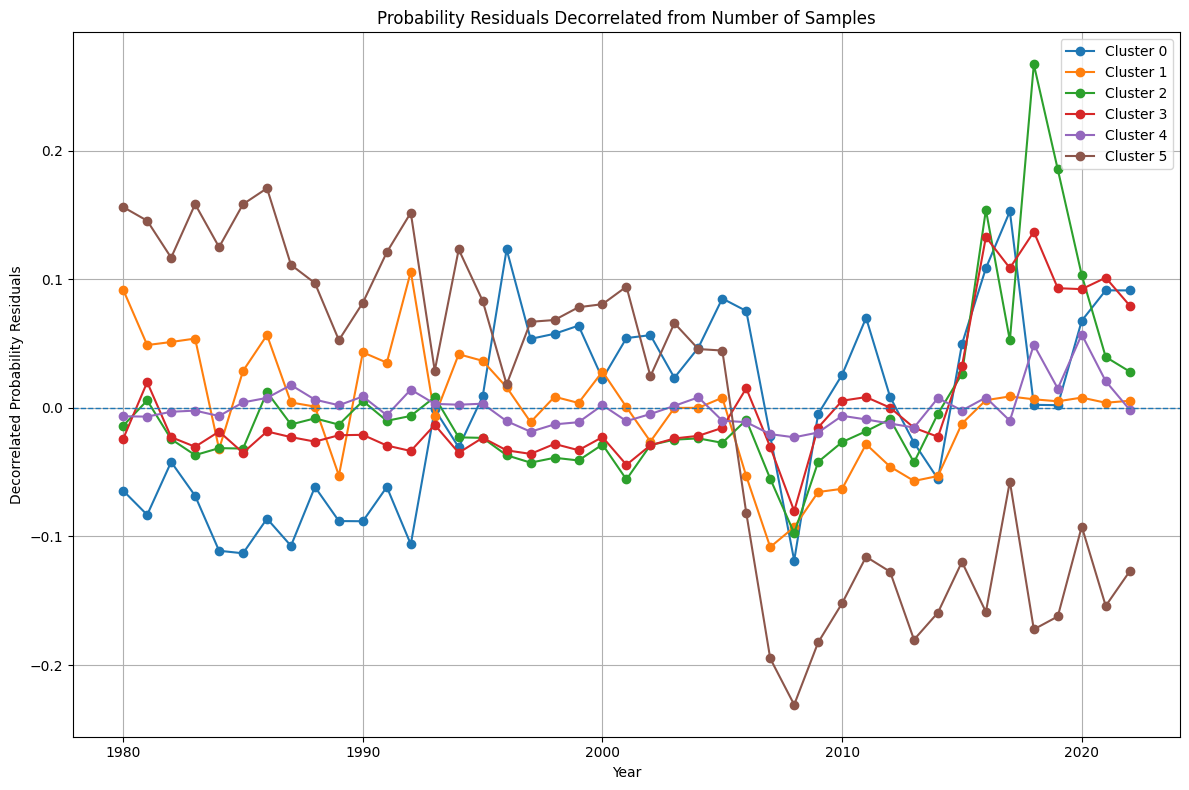

In [32]:
# Variance column names
prob_cols = [f'prob_mean_cluster_{i}' for i in range(n_clusters)]

# Plot decorrelated variance
plt.figure(figsize=(12, 8))

for i in range(n_clusters):
    col = f'prob_mean_cluster_{i}'

    plt.plot(
        decorrelated_probs.index,
        decorrelated_probs[col],
        marker='o',
        label=f'Cluster {i}'
    )

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title('Probability Residuals Decorrelated from Number of Samples')
plt.xlabel('Year')
plt.ylabel('Decorrelated Probability Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()